In [86]:
import maboss
import os
import matplotlib.pyplot as plt
from tools import change_inputs, to_istates

In [87]:
path = "../config/differentiation/boolean_network/"

In [88]:
bnd_file = os.path.join(path,"tcell_corral.bnd")
cfg_file = os.path.join(path,"tcell_corral.cfg")

tcell_sim = maboss.load(bnd_file, cfg_file)

In [89]:
input_tcell = ["IL1_In", "MHCII_b1", "MHCII_b2", "IL12_In", "IL6_In", "CD4", "CD80", "IL23_In", "PIP2"]

In [90]:
output_physiboss = ["IL12RB1" , "IL12RB2" , "GP130" , "STAT5B_b1" , "IL1RAP" , "IL1R1" , "STAT5B_b2" , "CXCR4", "IL2RB", "CGC"]
output_maboss = ["Treg", "Th17", "Th1"]
nodes_phenotype = ["FOXP3", "FOXP3_2", "RORGt", "Tbet", "CD4"]

In [91]:
input_tcell_dict = {element: 0 for element in input_tcell}

# Wild type Tcell
This is a simulation where all the nodes are 0. The starting point of the PysiBoSS simulation.


In [92]:
sim = tcell_sim.copy()
sim.network.set_output(output_physiboss)
sim.update_parameters(sample_count=1000,max_time=100, time_tick=0.5)
maboss.set_nodes_istate(sim, sim.network.keys(), [1, 0])

Warning, node PI3K_b1 was previously bound to other nodes
Warning, node Blimp1_b1 was previously bound to other nodes
Warning, node RUNX1_b1 was previously bound to other nodes
Warning, node NFAT2A_b1 was previously bound to other nodes
Warning, node STAT5B_b1 was previously bound to other nodes
Warning, node STAT5A_b1 was previously bound to other nodes
Warning, node MHCII_b1 was previously bound to other nodes
Warning, node TCR_b1 was previously bound to other nodes
Warning, node FOXP3 was previously bound to other nodes
Warning, node IL2R_b1 was previously bound to other nodes


In [93]:
sim.get_initial_state();

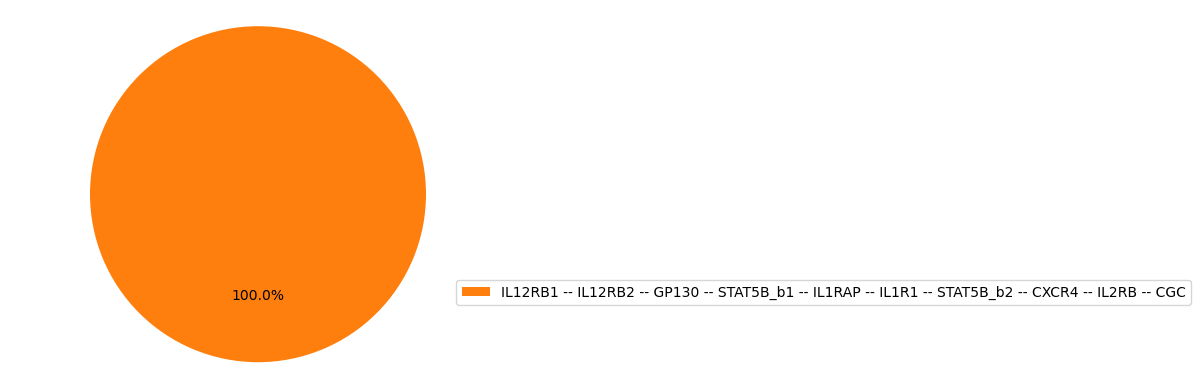

In [94]:
model = sim.run()

model.plot_piechart()

The result of the previous simulation shows that none of the phenotype nodes (Treg, Th17, Th1) are active. The dendritic cells while deliver their input to the tcell in this stable state.

In [95]:
nodes = list(sim.network.keys())
input_tcell_dict = {element: 1 for element in input_tcell}

Now we assign this state as initial state for a new simulation and on top of that we are going to activate the input nodes that the dendritic cells will activate in the PhysiBoSS simulation 

In [96]:
new_istates = change_inputs(nodes, to_istates(model.get_states_probtraj(), nodes), input_tcell_dict)

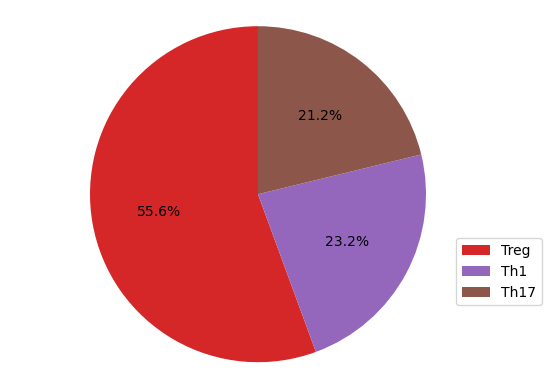

In [97]:
sim_next = sim.copy()
sim_next.network.set_output(output_maboss)
sim_next.update_parameters(sample_count=1000,max_time=100, time_tick=0.5)
sim_next.network.set_istate(nodes, new_istates)


model_activated = sim_next.run()

model_activated.plot_piechart()

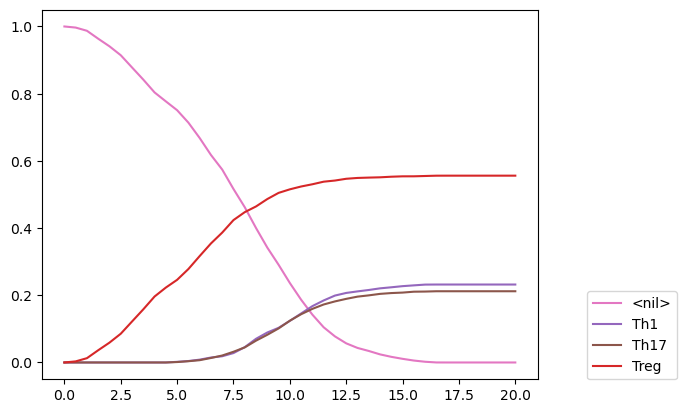

In [98]:
model_activated.plot_trajectory(until=20)

In [99]:
model_activated.get_states_probtraj().iloc[-1,:]

<nil>    0.000
Th1      0.232
Th17     0.212
Treg     0.556
Name: 99.0, dtype: float64

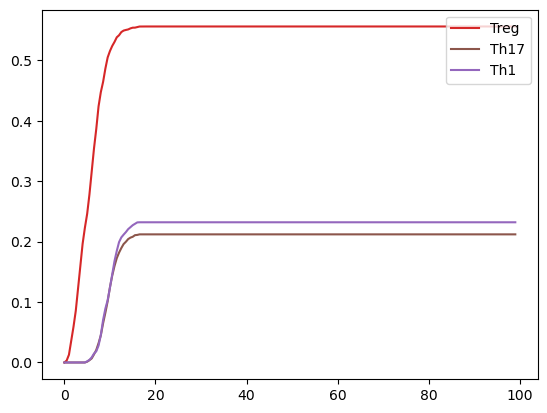

In [100]:
model_activated.plot_node_trajectory()

The input delivered by the dendritic cells, will allow the differentiation of the naive tcell into Treg, Th17 and Th1

# Analysis of the Mutants

## Single mutants

Now we are going to test a series of mutations in the model. To perform this kind of analysis, we are not going to test the mutations on the wild type state, but on the stable state prior to contact with the dendritic cells. Moreover, we are going to test the input delivered by the dendritic cells to those mutations results that did not trigger any differentiation. The objective of this analysis is to search for undifferentiated stable state of the network that are more vulnerable or more resistant to the dendritic cell contact.

In [101]:
def compute_input_on_mutations(model, res_mutations, nodes, inputs):
    new_results = {}
    for mutation_target in res_mutations:
        mutation_result = res_mutations[mutation_target]
        new_istates = change_inputs(nodes, to_istates(mutation_result.get_states_probtraj(), nodes), inputs)
        s_model = model.copy()
        s_model.network.set_istate(nodes, new_istates)

        new_results.update({mutation_target: s_model.run()})
    return new_results
        

In [102]:
sim_test_single_mut = sim.copy()
sim_test_single_mut.network.set_output(output_maboss)

In [103]:
nodes_test = ['PI3K_b1', 'PI3K_b2', 'IL6_Aut', 'IL12R', 'IL6R', 'STAT1', 'Tbet', 'AP1', 'NFAT1', 'NFKB', 'Blimp1_b1', 'Blimp1_b2', 'RUNX1_b1', 'RUNX1_b2', 'STAT4', 'RUNX3', 'EOMES', 'IFNg', 'IL12RB1', 'IL12RB2', 'IL1RAP', 'IL1R1', 'IL1R', 'IL23R', 'STAT3', 'cMAF', 'IL21', 'RORGt', 'IRF4', 'AHR', 'NFAT2A_b1', 'NFAT2A_b2', 'STAT5B_b1', 'STAT5B_b2', 'SMAD2', 'RORA', 'STAT5A_b1', 'STAT5A_b2', 'IL17A', 'IL17F', 'LCK', 'TCR_b1', 'TCR_b2', 'CD28', 'ZAP70', 'LAT', 'VAV', 'RAS', 'SOS', 'PLCG', 'RAC', 'FOXP3', 'PTEN', 'PIP3', 'IP3', 'DAG', 'PKCO', 'ITK_b1', 'ERK1_2', 'cFOS', 'cJUN', 'MEKK1', 'TRAF6', 'TAK1', 'IKK', 'Myd88', 'IRAK1_4', 'NFAT2', 'NFAT4', 'IL2RA', 'IL2RB', 'CGC', 'IL2', 'IL2R_b1', 'IL2R_b2', 'SATB1', 'TGFBR', 'GP130', 'MINA', 'FOXP3_2', 'TGFB_In', 'CXCR4', 'ITK_b2']

In [104]:
res_single = maboss.pipelines.simulate_single_mutants(sim_test_single_mut, nodes_test)

In the following cell, we filter the results because we want to test the input delivered by the mDCs on an undifferentiated population of T0.

In [105]:
filtered_res = maboss.pipelines.filter_sensitivity(res_single, node="Treg", maximum=0)
filtered_res = maboss.pipelines.filter_sensitivity(filtered_res, node="Th1", maximum=0)
filtered_res = maboss.pipelines.filter_sensitivity(filtered_res, node="Th17", maximum=0)

{('PI3K_b1', 'ON'): <maboss.result.Result at 0x7f3902300d40>,
 ('PI3K_b2', 'ON'): <maboss.result.Result at 0x7f38fff647a0>,
 ('IL6_Aut', 'ON'): <maboss.result.Result at 0x7f3901fb22d0>,
 ('IL12R', 'ON'): <maboss.result.Result at 0x7f38fffb5880>,
 ('IL6R', 'ON'): <maboss.result.Result at 0x7f38fff46900>,
 ('STAT1', 'ON'): <maboss.result.Result at 0x7f390038dd00>,
 ('AP1', 'ON'): <maboss.result.Result at 0x7f38fff65e20>,
 ('NFAT1', 'ON'): <maboss.result.Result at 0x7f39023029f0>,
 ('NFKB', 'ON'): <maboss.result.Result at 0x7f39024d9100>,
 ('Blimp1_b1', 'ON'): <maboss.result.Result at 0x7f3900244f80>,
 ('Blimp1_b2', 'ON'): <maboss.result.Result at 0x7f390004ea80>,
 ('RUNX1_b1', 'ON'): <maboss.result.Result at 0x7f39879b7b60>,
 ('RUNX1_b2', 'ON'): <maboss.result.Result at 0x7f38fffb7ec0>,
 ('STAT4', 'ON'): <maboss.result.Result at 0x7f38fff16d80>,
 ('RUNX3', 'ON'): <maboss.result.Result at 0x7f38fff451c0>,
 ('EOMES', 'ON'): <maboss.result.Result at 0x7f3902489100>,
 ('IFNg', 'ON'): <maboss

In [106]:
stable_state = sim.copy()
nodes = list(stable_state.network.keys())
inputs = input_tcell_dict = {element: 1 for element in input_tcell}
stable_state.network.set_output(output_maboss)

In [117]:
updated_mutations = compute_input_on_mutations(stable_state, filtered_res, nodes, inputs)

In [118]:
filtered_mutations_Treg = maboss.pipelines.filter_sensitivity(updated_mutations, node="Treg", maximum=0.468)

In [120]:
for mutant, res in filtered_mutations_Treg.items():
    print(mutant)
    res.plot_piechart()
    plt.title(mutant)

In [121]:
filtered_mutations_Th1 = maboss.pipelines.filter_sensitivity(updated_mutations, node="Th1", maximum=0.243)

In [123]:
for mutant, res in filtered_mutations_Th1.items():
    res.plot_piechart()
    plt.title(mutant)


In [124]:
filtered_mutations_Th17 = maboss.pipelines.filter_sensitivity(updated_mutations, node="Th17", maximum=0.196)

In [126]:
for mutant, res in filtered_mutations_Th17.items():
    res.plot_piechart()
    plt.title(mutant)

As we can observe, no single mutation resulted in a drastic change of the original model behavior. However, the single mutations reported above, can slightly change the cell population of the three cell types. This may have an impact on a very large number of cells.

## Double mutants

Next we are going to test a series of double mutations, in the same way as we did before.

In [29]:
sim_test_double_mut = sim.copy()
sim_test_double_mut.network.set_output(output_maboss)

nodes_test = ['PI3K_b1', 'PI3K_b2', 'IL6_Aut', 'IL12R', 'IL6R', 'STAT1', 'AP1', 'NFAT1', 'NFKB', 'Blimp1_b1', 'Blimp1_b2', 'RUNX1_b1', 'RUNX1_b2', 'STAT4', 'RUNX3', 'EOMES', 'IFNg', 'IL12RB1', 'IL12RB2', 'IL1RAP', 'IL1R1', 'IL1R', 'IL23R', 'STAT3', 'cMAF', 'IL21', 'IRF4', 'AHR', 'NFAT2A_b1', 'NFAT2A_b2', 'STAT5B_b1', 'STAT5B_b2', 'SMAD2', 'RORA', 'STAT5A_b1', 'STAT5A_b2', 'IL17A', 'IL17F', 'LCK', 'TCR_b1', 'TCR_b2', 'CD28', 'ZAP70', 'LAT', 'VAV', 'RAS', 'SOS', 'PLCG', 'RAC', 'PTEN', 'PIP3', 'IP3', 'DAG', 'PKCO', 'ITK_b1', 'ERK1_2', 'cFOS', 'cJUN', 'MEKK1', 'TRAF6', 'TAK1', 'IKK', 'Myd88', 'IRAK1_4', 'NFAT2', 'NFAT4', 'IL2RA', 'IL2RB', 'CGC', 'IL2', 'IL2R_b1', 'IL2R_b2', 'SATB1', 'TGFBR', 'GP130', 'MINA', 'TGFB_In', 'CXCR4', 'ITK_b2']

In [30]:
res_double = maboss.pipelines.simulate_double_mutants(sim_test_double_mut, nodes_test);

In [31]:
filtered_res_double_mut = maboss.pipelines.filter_sensitivity(res_double, node="Treg", maximum=0)
filtered_res_double_mut = maboss.pipelines.filter_sensitivity(filtered_res_double_mut, node="Th1", maximum=0)
filtered_res_double_mut = maboss.pipelines.filter_sensitivity(filtered_res_double_mut, node="Th17", maximum=0)

In [32]:
stable_state = sim.copy()
nodes = list(stable_state.network.keys())
inputs = input_tcell_dict = {element: 1 for element in input_tcell}
stable_state.network.set_output(output_maboss)

In [33]:
updated_double_mutations = compute_input_on_mutations(stable_state, filtered_res_double_mut, nodes, inputs)

In [34]:
filtered_res_double_mut_threg = maboss.pipelines.filter_sensitivity(updated_double_mutations, node="Treg", maximum=0.441)

In [35]:
for mutant, res in filtered_res_double_mut_threg.items():
    res.plot_piechart()
    plt.title(mutant)

In [36]:
filtered_res_double_mut_Th1 = maboss.pipelines.filter_sensitivity(updated_double_mutations, node="Th1", maximum=0.224)

In [37]:
for mutant, res in filtered_res_double_mut_Th1.items():
    res.plot_piechart()
    plt.title(mutant)

In [38]:
filtered_res_double_mut_th17 = maboss.pipelines.filter_sensitivity(updated_double_mutations, node="Th17", maximum=0.18)

In [39]:
for mutant, res in filtered_res_double_mut_th17.items():
    res.plot_piechart()
    plt.title(mutant)

The effect of the double mutations founded above is slightly better than the effect of the single mutations. Once again, at low number of cell population, this may not have visible effect, but it could have for a large number of cells.